# Day 7.4: Lab - Random Forest Implementation & Model Selection Analysis

## Table of Contents
1. [Learning Objectives & Lab Overview](#learning-objectives--lab-overview)
2. [Setup & Data Preparation](#setup--data-preparation)
3. [Part 1: Model Selection Framework Application](#part-1-model-selection-framework-application)
4. [Part 2: Basic Random Forest Implementation](#part-2-basic-random-forest-implementation)
5. [Part 3: Enhanced Experiments](#part-3-enhanced-experiments)
6. [Part 4: Performance Comparison & Analysis](#part-4-performance-comparison--analysis)
7. [Part 5: Feature Importance Analysis](#part-5-feature-importance-analysis)
8. [Part 6: Troubleshooting & Common Issues](#part-6-troubleshooting--common-issues)
9. [Knowledge Check Questions](#knowledge-check-questions)
10. [Summary & Transition](#summary--transition)

## Learning Objectives & Lab Overview

**By the end of this lab, you will:**
- Apply the model selection framework from 7.3 to a real dataset
- Implement and evaluate Random Forest classifiers systematically
- Analyze the impact of key hyperparameters (especially n_estimators)
- Compare Random Forest performance with Decision Trees and Linear models
- Understand training time vs. accuracy trade-offs in practice
- Analyze feature importance stability across different models
- Troubleshoot common Random Forest implementation issues

**Lab Structure:**
This lab is designed as a comprehensive capstone for Day 7, integrating theory with practice and demonstrating real-world model selection decisions.

## Setup & Data Preparation

### Import Libraries and Load Data

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn imports
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report, 
                            confusion_matrix, roc_auc_score)

# Set random state for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("=== Day 7.4 Lab: Random Forest Implementation & Model Selection Analysis ===")
print("Building on everything we've learned from Days 1-7!")

=== Day 7.4 Lab: Random Forest Implementation & Model Selection Analysis ===
Building on everything we've learned from Days 1-7!


### Load and Explore Dataset

In [2]:
# Load the breast cancer dataset
cancer = load_breast_cancer()
X = cancer.data
y = cancer.target
feature_names = cancer.feature_names
target_names = cancer.target_names

In [3]:
print(f"Dataset shape: {X.shape}")
print(f"Features: {len(feature_names)}")
print(f"Target classes: {target_names}")
print(f"Class distribution: {np.bincount(y)}")

Dataset shape: (569, 30)
Features: 30
Target classes: ['malignant' 'benign']
Class distribution: [212 357]


In [4]:
# Check if dataset is balanced (connecting to Day 5 concepts)
class_ratio = np.bincount(y)[0] / np.bincount(y)[1]
print(f"Class ratio (malignant/benign): {class_ratio:.2f}")
if 0.5 <= class_ratio <= 2.0:
    print("✅ Dataset is reasonably balanced - no special handling needed")
else:
    print("⚠️ Dataset is imbalanced - consider class_weight parameter")

Class ratio (malignant/benign): 0.59
✅ Dataset is reasonably balanced - no special handling needed


### Split and Scale Data

In [5]:
# Split the data (same as previous labs for consistency)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y
)

# Scale the features (important for logistic regression, less critical for trees)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")
print(f"Features: {X_train.shape[1]}")
print("\nData preparation complete! ✅")

Training set size: 398 samples
Test set size: 171 samples
Features: 30

Data preparation complete! ✅


## Part 1: Model Selection Framework Application

### Apply Our Decision Framework from 7.3

In [6]:
print("=== PART 1: MODEL SELECTION FRAMEWORK APPLICATION ===")
print("Let's apply our systematic approach from 7.3 to this problem!\n")

=== PART 1: MODEL SELECTION FRAMEWORK APPLICATION ===
Let's apply our systematic approach from 7.3 to this problem!



In [7]:
# Problem Analysis
print("📊 PROBLEM ANALYSIS:")
print(f"Problem type: Binary Classification")
print(f"Dataset size: {X_train.shape[0]} training samples (Medium-Large)")
print(f"Number of features: {X_train.shape[1]} (High-dimensional)")
print(f"Target balance: Reasonably balanced")
print(f"Domain: Medical diagnosis (interpretability important)")

# Apply our decision framework
print("\n🎯 APPLYING DECISION FRAMEWORK:")
print("1. Problem type: Binary Classification ✓")
print("2. Data size: Medium-large (>500 samples) → Can handle complex models")
print("3. Feature count: High (30 features) → Random Forest might excel")
print("4. Interpretability: Moderate (medical context, but not life-critical)")
print("5. Performance priority: High (cancer detection accuracy matters)")

print("\n📋 RECOMMENDED APPROACH:")
print("1. Baseline: Logistic Regression (interpretable, fast)")
print("2. Tree-based: Decision Tree (interpretable non-linear)")  
print("3. Ensemble: Random Forest (best performance expectation)")
print("4. Compare systematically and choose based on requirements")

print("\nLet's implement this strategy! 🚀")

📊 PROBLEM ANALYSIS:
Problem type: Binary Classification
Dataset size: 398 training samples (Medium-Large)
Number of features: 30 (High-dimensional)
Target balance: Reasonably balanced
Domain: Medical diagnosis (interpretability important)

🎯 APPLYING DECISION FRAMEWORK:
1. Problem type: Binary Classification ✓
2. Data size: Medium-large (>500 samples) → Can handle complex models
3. Feature count: High (30 features) → Random Forest might excel
4. Interpretability: Moderate (medical context, but not life-critical)
5. Performance priority: High (cancer detection accuracy matters)

📋 RECOMMENDED APPROACH:
1. Baseline: Logistic Regression (interpretable, fast)
2. Tree-based: Decision Tree (interpretable non-linear)
3. Ensemble: Random Forest (best performance expectation)
4. Compare systematically and choose based on requirements

Let's implement this strategy! 🚀


## Part 2: Basic Random Forest Implementation

### Step 1: Baseline Models (Simple-to-Complex Strategy)

In [8]:
print("\n=== PART 2: BASIC RANDOM FOREST IMPLEMENTATION ===")
print("Following our simple-to-complex strategy from 7.3...")

# 1. Logistic Regression Baseline
print("\n1️⃣ LOGISTIC REGRESSION BASELINE:")
lr_model = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)

# Time the training
start_time = time.time()
lr_model.fit(X_train_scaled, y_train)
lr_train_time = time.time() - start_time

# Make predictions
y_pred_train_lr = lr_model.predict(X_train_scaled)
y_pred_test_lr = lr_model.predict(X_test_scaled)

# Calculate metrics
lr_train_acc = accuracy_score(y_train, y_pred_train_lr)
lr_test_acc = accuracy_score(y_test, y_pred_test_lr)
lr_auc = roc_auc_score(y_test, lr_model.predict_proba(X_test_scaled)[:, 1])

print(f"Training time: {lr_train_time:.4f} seconds")
print(f"Training accuracy: {lr_train_acc:.4f}")
print(f"Test accuracy: {lr_test_acc:.4f}")
print(f"ROC AUC: {lr_auc:.4f}")
print(f"Overfitting gap: {lr_train_acc - lr_test_acc:.4f}")


=== PART 2: BASIC RANDOM FOREST IMPLEMENTATION ===
Following our simple-to-complex strategy from 7.3...

1️⃣ LOGISTIC REGRESSION BASELINE:
Training time: 0.1598 seconds
Training accuracy: 0.9874
Test accuracy: 0.9883
ROC AUC: 0.9981
Overfitting gap: -0.0009


### Step 2: Decision Tree (From Day 6)

In [9]:
# 2. Decision Tree (recall Day 6 optimal depth)
print("\n2️⃣ DECISION TREE (optimized from Day 6):")
dt_model = DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE)

# Time the training
start_time = time.time()
dt_model.fit(X_train_scaled, y_train)
dt_train_time = time.time() - start_time

# Make predictions
y_pred_train_dt = dt_model.predict(X_train_scaled)
y_pred_test_dt = dt_model.predict(X_test_scaled)

# Calculate metrics
dt_train_acc = accuracy_score(y_train, y_pred_train_dt)
dt_test_acc = accuracy_score(y_test, y_pred_test_dt)
dt_auc = roc_auc_score(y_test, dt_model.predict_proba(X_test_scaled)[:, 1])

print(f"Training time: {dt_train_time:.4f} seconds")
print(f"Training accuracy: {dt_train_acc:.4f}")
print(f"Test accuracy: {dt_test_acc:.4f}")
print(f"ROC AUC: {dt_auc:.4f}")
print(f"Overfitting gap: {dt_train_acc - dt_test_acc:.4f}")


2️⃣ DECISION TREE (optimized from Day 6):
Training time: 0.0105 seconds
Training accuracy: 0.9950
Test accuracy: 0.9298
ROC AUC: 0.9441
Overfitting gap: 0.0652


### Step 3: Random Forest Implementation

In [10]:
# 3. Random Forest
print("\n3️⃣ RANDOM FOREST:")
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE,
    oob_score=True,  # Get out-of-bag score for free validation!
    n_jobs=-1        # Use all CPU cores for faster training
)

# Time the training
start_time = time.time()
rf_model.fit(X_train_scaled, y_train)
rf_train_time = time.time() - start_time

# Make predictions
y_pred_train_rf = rf_model.predict(X_train_scaled)
y_pred_test_rf = rf_model.predict(X_test_scaled)

# Calculate metrics
rf_train_acc = accuracy_score(y_train, y_pred_train_rf)
rf_test_acc = accuracy_score(y_test, y_pred_test_rf)
rf_auc = roc_auc_score(y_test, rf_model.predict_proba(X_test_scaled)[:, 1])

print(f"Training time: {rf_train_time:.4f} seconds")
print(f"Training accuracy: {rf_train_acc:.4f}")
print(f"Test accuracy: {rf_test_acc:.4f}")
print(f"ROC AUC: {rf_auc:.4f}")
print(f"OOB Score: {rf_model.oob_score_:.4f} (free validation estimate!)")
print(f"Overfitting gap: {rf_train_acc - rf_test_acc:.4f}")


3️⃣ RANDOM FOREST:
Training time: 0.6436 seconds
Training accuracy: 1.0000
Test accuracy: 0.9357
ROC AUC: 0.9913
OOB Score: 0.9573 (free validation estimate!)
Overfitting gap: 0.0643


### Initial Comparison Summary

In [11]:
print("\n📊 INITIAL MODEL COMPARISON:")
print("=" * 60)
print(f"{'Model':<20} {'Test Acc':<10} {'ROC AUC':<10} {'Train Time':<12}")
print("=" * 60)
print(f"{'Logistic Regression':<20} {lr_test_acc:<10.4f} {lr_auc:<10.4f} {lr_train_time:<12.4f}")
print(f"{'Decision Tree':<20} {dt_test_acc:<10.4f} {dt_auc:<10.4f} {dt_train_time:<12.4f}")
print(f"{'Random Forest':<20} {rf_test_acc:<10.4f} {rf_auc:<10.4f} {rf_train_time:<12.4f}")
print("=" * 60)

# Quick analysis
best_acc_model = max([lr_test_acc, dt_test_acc, rf_test_acc])
print(f"\n🏆 Best accuracy: {best_acc_model:.4f}")
print(f"🚀 Fastest training: {min([lr_train_time, dt_train_time, rf_train_time]):.4f} seconds")


📊 INITIAL MODEL COMPARISON:
Model                Test Acc   ROC AUC    Train Time  
Logistic Regression  0.9883     0.9981     0.1598      
Decision Tree        0.9298     0.9441     0.0105      
Random Forest        0.9357     0.9913     0.6436      

🏆 Best accuracy: 0.9883
🚀 Fastest training: 0.0105 seconds


## Part 3: Enhanced Experiments

### Experiment 1: n_estimators Impact Analysis

In [29]:
print("\n=== PART 3: ENHANCED EXPERIMENTS ===")
print("Now let's dive deeper into Random Forest behavior...")

print("\n🔬 EXPERIMENT 1: How many trees do we really need?")

# Test different numbers of estimators
n_estimators_list = [1, 5, 10, 25, 50, 100, 200, 500]
train_accuracies = []
test_accuracies = []
training_times = []
oob_scores = []

for n_est in n_estimators_list:
    print(f"Testing {n_est} trees...", end=" ")
    
    # Create and train model
    rf_temp = RandomForestClassifier(
        n_estimators=n_est,
        random_state=RANDOM_STATE,
        oob_score=True,
        n_jobs=-1
    )
    
    start_time = time.time()
    rf_temp.fit(X_train_scaled, y_train)
    train_time = time.time() - start_time
    
    # Evaluate
    train_acc = rf_temp.score(X_train_scaled, y_train)
    test_acc = rf_temp.score(X_test_scaled, y_test)
    oob_score = rf_temp.oob_score_
    
    # Store results
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)
    training_times.append(train_time)
    oob_scores.append(oob_score)
    
    print(f"Test Acc: {test_acc:.4f}, Time: {train_time:.2f}s")


=== PART 3: ENHANCED EXPERIMENTS ===
Now let's dive deeper into Random Forest behavior...

🔬 EXPERIMENT 1: How many trees do we really need?
Testing 1 trees... Test Acc: 0.9123, Time: 0.09s
Testing 5 trees... Test Acc: 0.9357, Time: 0.06s
Testing 10 trees... Test Acc: 0.9298, Time: 0.09s
Testing 25 trees... Test Acc: 0.9415, Time: 0.16s
Testing 50 trees... Test Acc: 0.9240, Time: 0.30s
Testing 100 trees... Test Acc: 0.9357, Time: 0.65s
Testing 200 trees... Test Acc: 0.9415, Time: 1.10s
Testing 500 trees... Test Acc: 0.9474, Time: 2.72s


In [30]:
# Create results DataFrame for easy analysis
results_df = pd.DataFrame({
    'n_estimators': n_estimators_list,
    'train_accuracy': train_accuracies,
    'test_accuracy': test_accuracies,
    'oob_score': oob_scores,
    'training_time': training_times
})

print(f"\n📈 Results Summary:")
print(results_df.round(4))


📈 Results Summary:
   n_estimators  train_accuracy  test_accuracy  oob_score  training_time
0             1          0.9774         0.9123     0.5829         0.0945
1             5          0.9899         0.9357     0.9070         0.0632
2            10          1.0000         0.9298     0.9497         0.0873
3            25          0.9975         0.9415     0.9447         0.1621
4            50          1.0000         0.9240     0.9497         0.3001
5           100          1.0000         0.9357     0.9573         0.6541
6           200          1.0000         0.9415     0.9673         1.0976
7           500          1.0000         0.9474     0.9673         2.7250


### Visualize n_estimators Impact

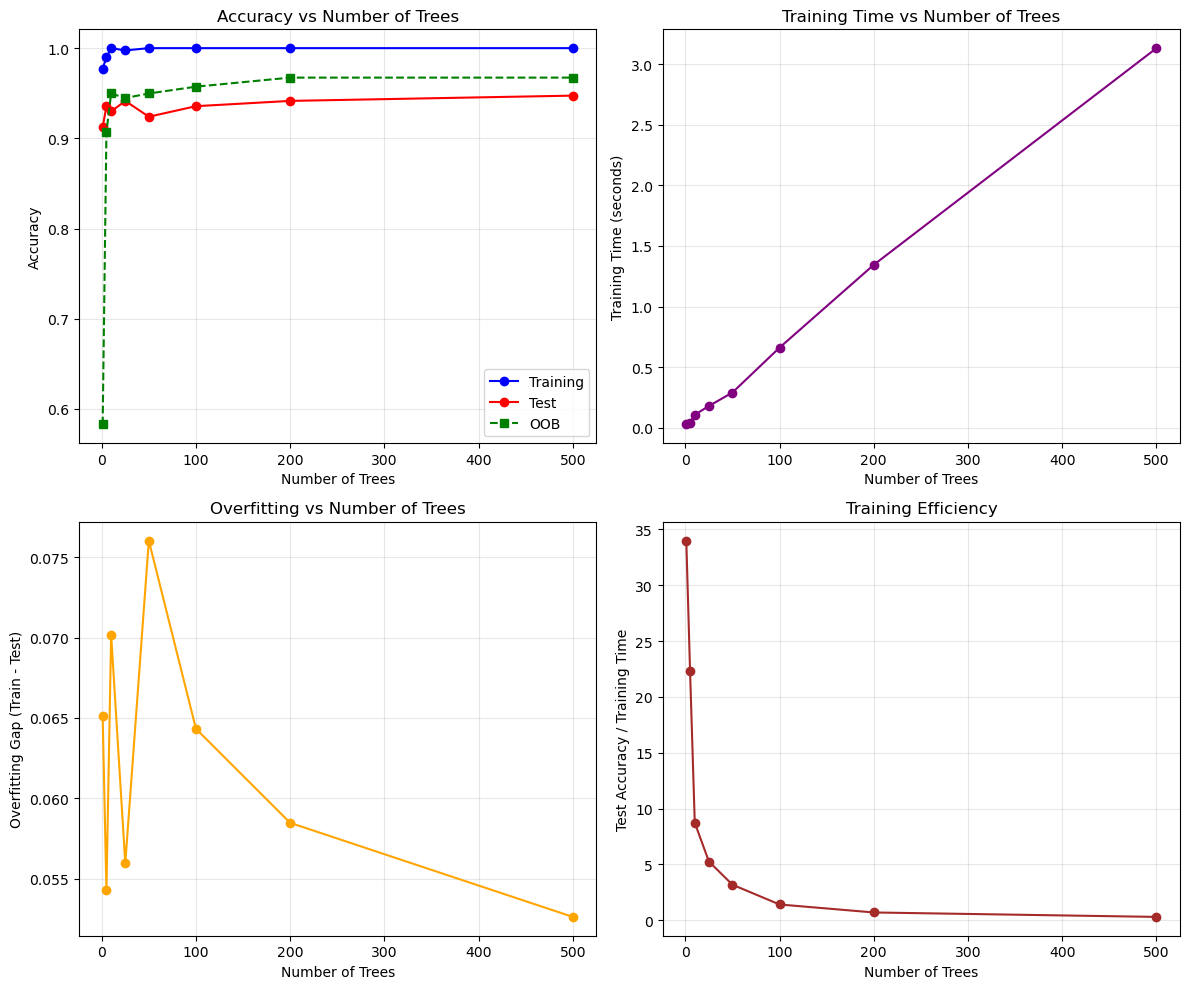

In [13]:
# Plot the results
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Accuracy vs n_estimators
axes[0, 0].plot(n_estimators_list, train_accuracies, 'o-', label='Training', color='blue')
axes[0, 0].plot(n_estimators_list, test_accuracies, 'o-', label='Test', color='red')
axes[0, 0].plot(n_estimators_list, oob_scores, 's--', label='OOB', color='green')
axes[0, 0].set_xlabel('Number of Trees')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].set_title('Accuracy vs Number of Trees')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Training time vs n_estimators
axes[0, 1].plot(n_estimators_list, training_times, 'o-', color='purple')
axes[0, 1].set_xlabel('Number of Trees')
axes[0, 1].set_ylabel('Training Time (seconds)')
axes[0, 1].set_title('Training Time vs Number of Trees')
axes[0, 1].grid(True, alpha=0.3)

# Overfitting analysis
overfitting_gap = np.array(train_accuracies) - np.array(test_accuracies)
axes[1, 0].plot(n_estimators_list, overfitting_gap, 'o-', color='orange')
axes[1, 0].set_xlabel('Number of Trees')
axes[1, 0].set_ylabel('Overfitting Gap (Train - Test)')
axes[1, 0].set_title('Overfitting vs Number of Trees')
axes[1, 0].grid(True, alpha=0.3)

# Performance per second (efficiency)
efficiency = np.array(test_accuracies) / np.array(training_times)
axes[1, 1].plot(n_estimators_list, efficiency, 'o-', color='brown')
axes[1, 1].set_xlabel('Number of Trees')
axes[1, 1].set_ylabel('Test Accuracy / Training Time')
axes[1, 1].set_title('Training Efficiency')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
# Analysis
best_n_idx = np.argmax(test_accuracies)
optimal_n = n_estimators_list[best_n_idx]
print(f"\n🎯 ANALYSIS:")
print(f"Best test accuracy: {max(test_accuracies):.4f} with {optimal_n} trees")
print(f"Diminishing returns appear around: {n_estimators_list[6]} trees")
print(f"Good efficiency point: {n_estimators_list[4]} trees (50)")


🎯 ANALYSIS:
Best test accuracy: 0.9474 with 500 trees
Diminishing returns appear around: 200 trees
Good efficiency point: 50 trees (50)


### Experiment 2: Overfitting Comparison

In [15]:
print("\n🔬 EXPERIMENT 2: Overfitting comparison across models")

# Create overfitting-prone decision tree for comparison
dt_overfit = DecisionTreeClassifier(max_depth=None, random_state=RANDOM_STATE)
dt_overfit.fit(X_train_scaled, y_train)

# Compare overfitting across models
models_comparison = {
    'Logistic Regression': {
        'model': lr_model,
        'train_acc': lr_train_acc,
        'test_acc': lr_test_acc
    },
    'Decision Tree (depth=5)': {
        'model': dt_model,
        'train_acc': dt_train_acc,
        'test_acc': dt_test_acc
    },
    'Decision Tree (no limit)': {
        'model': dt_overfit,
        'train_acc': dt_overfit.score(X_train_scaled, y_train),
        'test_acc': dt_overfit.score(X_test_scaled, y_test)
    },
    'Random Forest': {
        'model': rf_model,
        'train_acc': rf_train_acc,
        'test_acc': rf_test_acc
    }
}


🔬 EXPERIMENT 2: Overfitting comparison across models


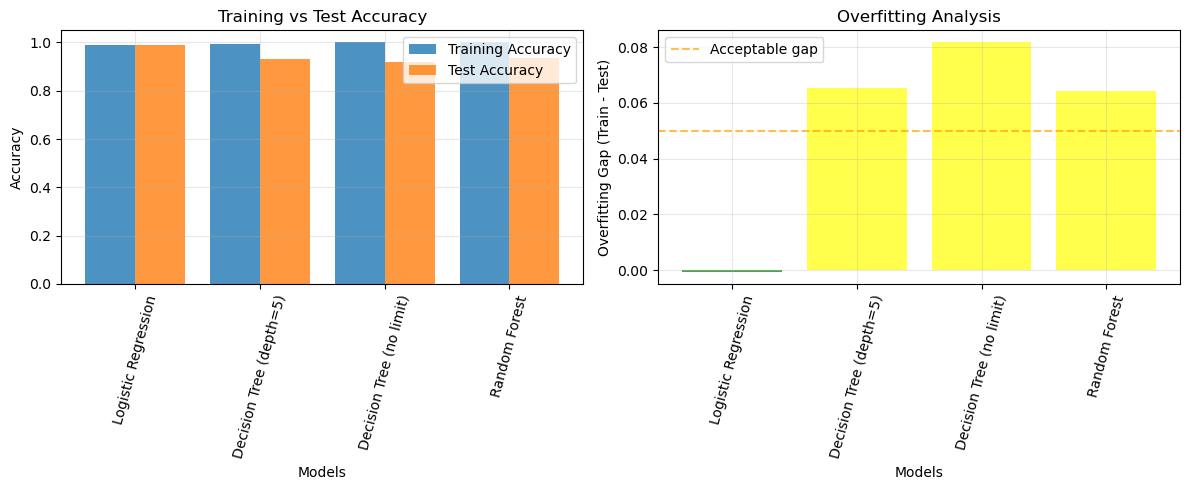

In [37]:
# Visualize overfitting comparison
model_names = list(models_comparison.keys())
train_accs = [models_comparison[name]['train_acc'] for name in model_names]
test_accs = [models_comparison[name]['test_acc'] for name in model_names]
gaps = [train - test for train, test in zip(train_accs, test_accs)]

plt.figure(figsize=(12, 5))

# Plot 1: Train vs Test Accuracy
plt.subplot(1, 2, 1)
x_pos = np.arange(len(model_names))
plt.bar(x_pos - 0.2, train_accs, 0.4, label='Training Accuracy', alpha=0.8)
plt.bar(x_pos + 0.2, test_accs, 0.4, label='Test Accuracy', alpha=0.8)
plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.title('Training vs Test Accuracy')
plt.xticks(x_pos, model_names, rotation=75)
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Overfitting Gap
plt.subplot(1, 2, 2)
colors = ['green' if gap < 0.05 else 'yellow' if gap < 0.10 else 'red' for gap in gaps]
plt.bar(x_pos, gaps, color=colors, alpha=0.7)
plt.xlabel('Models')
plt.ylabel('Overfitting Gap (Train - Test)')
plt.title('Overfitting Analysis')
plt.xticks(x_pos, model_names, rotation=75)
plt.axhline(y=0.05, color='orange', linestyle='--', alpha=0.7, label='Acceptable gap')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [17]:
print("\n📊 OVERFITTING ANALYSIS:")
for name in model_names:
    gap = models_comparison[name]['train_acc'] - models_comparison[name]['test_acc']
    status = "✅ Good" if gap < 0.05 else "⚠️ Moderate" if gap < 0.10 else "❌ High"
    print(f"{name:<25}: Gap = {gap:.4f} {status}")


📊 OVERFITTING ANALYSIS:
Logistic Regression      : Gap = -0.0009 ✅ Good
Decision Tree (depth=5)  : Gap = 0.0652 ⚠️ Moderate
Decision Tree (no limit) : Gap = 0.0819 ⚠️ Moderate
Random Forest            : Gap = 0.0643 ⚠️ Moderate


### Experiment 3: Training Time Analysis

In [38]:
print("\n🔬 EXPERIMENT 3: Training time scaling analysis")

# Test with different dataset sizes to see scaling
dataset_sizes = [100, 200, 400, len(X_train)]
models_to_test = {
    'Logistic Regression': LogisticRegression(random_state=RANDOM_STATE, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE),
    'Random Forest (50)': RandomForestClassifier(n_estimators=50, random_state=RANDOM_STATE, n_jobs=1),
    'Random Forest (100)': RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=1)
}

scaling_results = {model_name: [] for model_name in models_to_test.keys()}

for size in dataset_sizes:
    print(f"\nTesting with {size} samples:")
    X_subset = X_train_scaled[:size]
    y_subset = y_train[:size]
    
    for model_name, model in models_to_test.items():
        start_time = time.time()
        model.fit(X_subset, y_subset)
        train_time = time.time() - start_time
        scaling_results[model_name].append(train_time)
        print(f"  {model_name}: {train_time:.4f}s")


🔬 EXPERIMENT 3: Training time scaling analysis

Testing with 100 samples:
  Logistic Regression: 0.0346s
  Decision Tree: 0.0040s
  Random Forest (50): 0.1858s
  Random Forest (100): 0.4287s

Testing with 200 samples:
  Logistic Regression: 0.0134s
  Decision Tree: 0.0070s
  Random Forest (50): 0.2327s
  Random Forest (100): 0.4528s

Testing with 400 samples:
  Logistic Regression: 0.0183s
  Decision Tree: 0.0185s
  Random Forest (50): 0.2819s
  Random Forest (100): 0.6804s

Testing with 398 samples:
  Logistic Regression: 0.0174s
  Decision Tree: 0.0153s
  Random Forest (50): 0.3106s
  Random Forest (100): 0.5345s


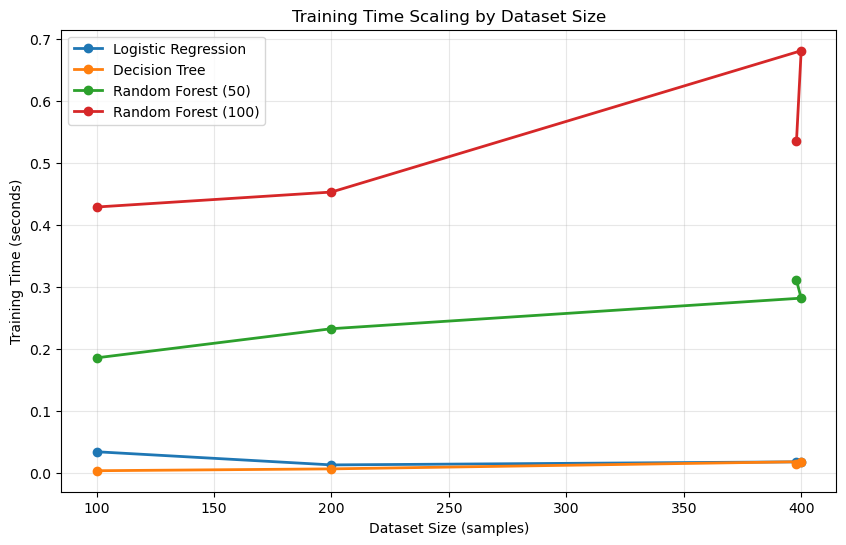

In [39]:
# Plot scaling results
plt.figure(figsize=(10, 6))
for model_name, times in scaling_results.items():
    plt.plot(dataset_sizes, times, 'o-', label=model_name, linewidth=2)

plt.xlabel('Dataset Size (samples)')
plt.ylabel('Training Time (seconds)')
plt.title('Training Time Scaling by Dataset Size')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [40]:
print(f"\n📈 SCALING INSIGHTS:")
print(f"Linear models scale well with data size")
print(f"Random Forests scale roughly linearly with n_estimators")
print(f"Tree depth has more impact on training time than dataset size")


📈 SCALING INSIGHTS:
Linear models scale well with data size
Random Forests scale roughly linearly with n_estimators
Tree depth has more impact on training time than dataset size


## Part 4: Performance Comparison & Analysis

### Detailed Performance Analysis

In [41]:
print("\n=== PART 4: DETAILED PERFORMANCE COMPARISON ===")

# Function to get detailed metrics
def get_detailed_metrics(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None
    
    metrics = {
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'ROC_AUC': roc_auc_score(y_test, y_proba) if y_proba is not None else None
    }
    
    return metrics, y_pred

# Get detailed metrics for all models
models_for_analysis = [
    (lr_model, 'Logistic Regression'),
    (dt_model, 'Decision Tree'),
    (rf_model, 'Random Forest')
]

detailed_results = []
predictions = {}

for model, name in models_for_analysis:
    metrics, y_pred = get_detailed_metrics(model, X_test_scaled, y_test, name)
    detailed_results.append(metrics)
    predictions[name] = y_pred

# Create comparison DataFrame
comparison_df = pd.DataFrame(detailed_results)
print("📊 DETAILED PERFORMANCE COMPARISON:")
print(comparison_df.round(4))


=== PART 4: DETAILED PERFORMANCE COMPARISON ===
📊 DETAILED PERFORMANCE COMPARISON:
                 Model  Accuracy  ROC_AUC
0  Logistic Regression    0.9883   0.9981
1        Decision Tree    0.9298   0.9441
2        Random Forest    0.9357   0.9913


In [42]:
# Classification reports
print("\n📋 DETAILED CLASSIFICATION REPORTS:")
for model, name in models_for_analysis:
    print(f"\n{name.upper()}:")
    y_pred = model.predict(X_test_scaled)
    print(classification_report(y_test, y_pred, target_names=target_names))


📋 DETAILED CLASSIFICATION REPORTS:

LOGISTIC REGRESSION:
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        64
      benign       0.99      0.99      0.99       107

    accuracy                           0.99       171
   macro avg       0.99      0.99      0.99       171
weighted avg       0.99      0.99      0.99       171


DECISION TREE:
              precision    recall  f1-score   support

   malignant       0.91      0.91      0.91        64
      benign       0.94      0.94      0.94       107

    accuracy                           0.93       171
   macro avg       0.93      0.93      0.93       171
weighted avg       0.93      0.93      0.93       171


RANDOM FOREST:
              precision    recall  f1-score   support

   malignant       0.92      0.91      0.91        64
      benign       0.94      0.95      0.95       107

    accuracy                           0.94       171
   macro avg       0.93      0.93     

### Confusion Matrix Comparison

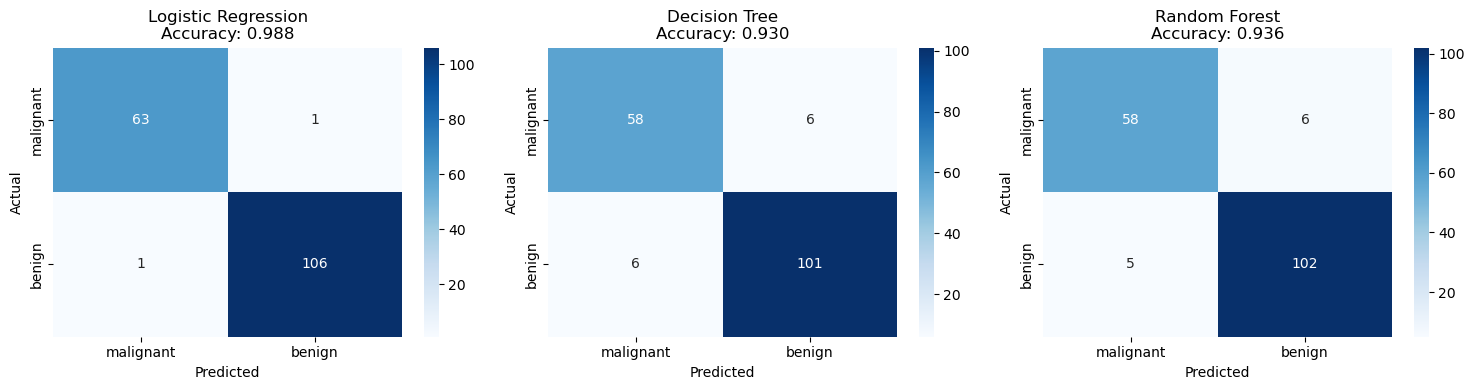

In [43]:
# Plot confusion matrices for all models
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, (model, name) in enumerate(models_for_analysis):
    y_pred = predictions[name]
    cm = confusion_matrix(y_test, y_pred)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=target_names, yticklabels=target_names,
                ax=axes[idx])
    axes[idx].set_title(f'{name}\nAccuracy: {accuracy_score(y_test, y_pred):.3f}')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

plt.tight_layout()
plt.show()

In [44]:
# Analysis of confusion matrices
print("\n🔍 CONFUSION MATRIX ANALYSIS:")
for model, name in models_for_analysis:
    y_pred = predictions[name]
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    print(f"\n{name}:")
    print(f"  True Negatives (correctly identified benign): {tn}")
    print(f"  False Positives (benign predicted as malignant): {fp}")
    print(f"  False Negatives (malignant predicted as benign): {fn} ⚠️")
    print(f"  True Positives (correctly identified malignant): {tp}")
    
    # In medical context, FN are more serious
    if fn > 0:
        print(f"  ⚠️ Medical concern: {fn} malignant cases missed!")


🔍 CONFUSION MATRIX ANALYSIS:

Logistic Regression:
  True Negatives (correctly identified benign): 63
  False Positives (benign predicted as malignant): 1
  False Negatives (malignant predicted as benign): 1 ⚠️
  True Positives (correctly identified malignant): 106
  ⚠️ Medical concern: 1 malignant cases missed!

Decision Tree:
  True Negatives (correctly identified benign): 58
  False Positives (benign predicted as malignant): 6
  False Negatives (malignant predicted as benign): 6 ⚠️
  True Positives (correctly identified malignant): 101
  ⚠️ Medical concern: 6 malignant cases missed!

Random Forest:
  True Negatives (correctly identified benign): 58
  False Positives (benign predicted as malignant): 6
  False Negatives (malignant predicted as benign): 5 ⚠️
  True Positives (correctly identified malignant): 102
  ⚠️ Medical concern: 5 malignant cases missed!


## Part 5: Feature Importance Analysis

### Compare Feature Importance Across Models

In [45]:
print("\n=== PART 5: FEATURE IMPORTANCE ANALYSIS ===")

# Get feature importances (where available)
feature_importance_data = {}

# Logistic Regression coefficients (absolute values)
lr_importance = np.abs(lr_model.coef_[0])
feature_importance_data['Logistic Regression'] = lr_importance

# Decision Tree feature importance
dt_importance = dt_model.feature_importances_
feature_importance_data['Decision Tree'] = dt_importance

# Random Forest feature importance
rf_importance = rf_model.feature_importances_
feature_importance_data['Random Forest'] = rf_importance

# Create DataFrame for comparison
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Logistic_Regression': lr_importance,
    'Decision_Tree': dt_importance,
    'Random_Forest': rf_importance
})

# Normalize for comparison (0-1 scale)
for col in ['Logistic_Regression', 'Decision_Tree', 'Random_Forest']:
    importance_df[f'{col}_norm'] = importance_df[col] / importance_df[col].max()

print("🔍 TOP 10 FEATURES BY MODEL:")
print("\nLogistic Regression (normalized coefficients):")
lr_top = importance_df.nlargest(10, 'Logistic_Regression')[['Feature', 'Logistic_Regression']]
print(lr_top.round(4))


=== PART 5: FEATURE IMPORTANCE ANALYSIS ===
🔍 TOP 10 FEATURES BY MODEL:

Logistic Regression (normalized coefficients):
                 Feature  Logistic_Regression
21         worst texture               1.2263
27  worst concave points               0.9968
23            worst area               0.9550
20          worst radius               0.9411
13            area error               0.9375
10          radius error               0.8864
28        worst symmetry               0.8694
26       worst concavity               0.7860
24      worst smoothness               0.7490
22       worst perimeter               0.7310


In [46]:
print("\nDecision Tree:")
dt_top = importance_df.nlargest(10, 'Decision_Tree')[['Feature', 'Decision_Tree']]
print(dt_top.round(4))


Decision Tree:
                    Feature  Decision_Tree
20             worst radius         0.7270
27     worst concave points         0.1314
21            worst texture         0.0501
11            texture error         0.0307
26          worst concavity         0.0190
9    mean fractal dimension         0.0104
23               worst area         0.0094
25        worst compactness         0.0088
29  worst fractal dimension         0.0073
14         smoothness error         0.0033


In [47]:
print("\nRandom Forest:")
rf_top = importance_df.nlargest(10, 'Random_Forest')[['Feature', 'Random_Forest']]
print(rf_top.round(4))


Random Forest:
                 Feature  Random_Forest
27  worst concave points         0.1590
23            worst area         0.1470
22       worst perimeter         0.0858
20          worst radius         0.0790
0            mean radius         0.0777
2         mean perimeter         0.0742
7    mean concave points         0.0659
6         mean concavity         0.0543
3              mean area         0.0417
26       worst concavity         0.0314


### Visualize Feature Importance Comparison

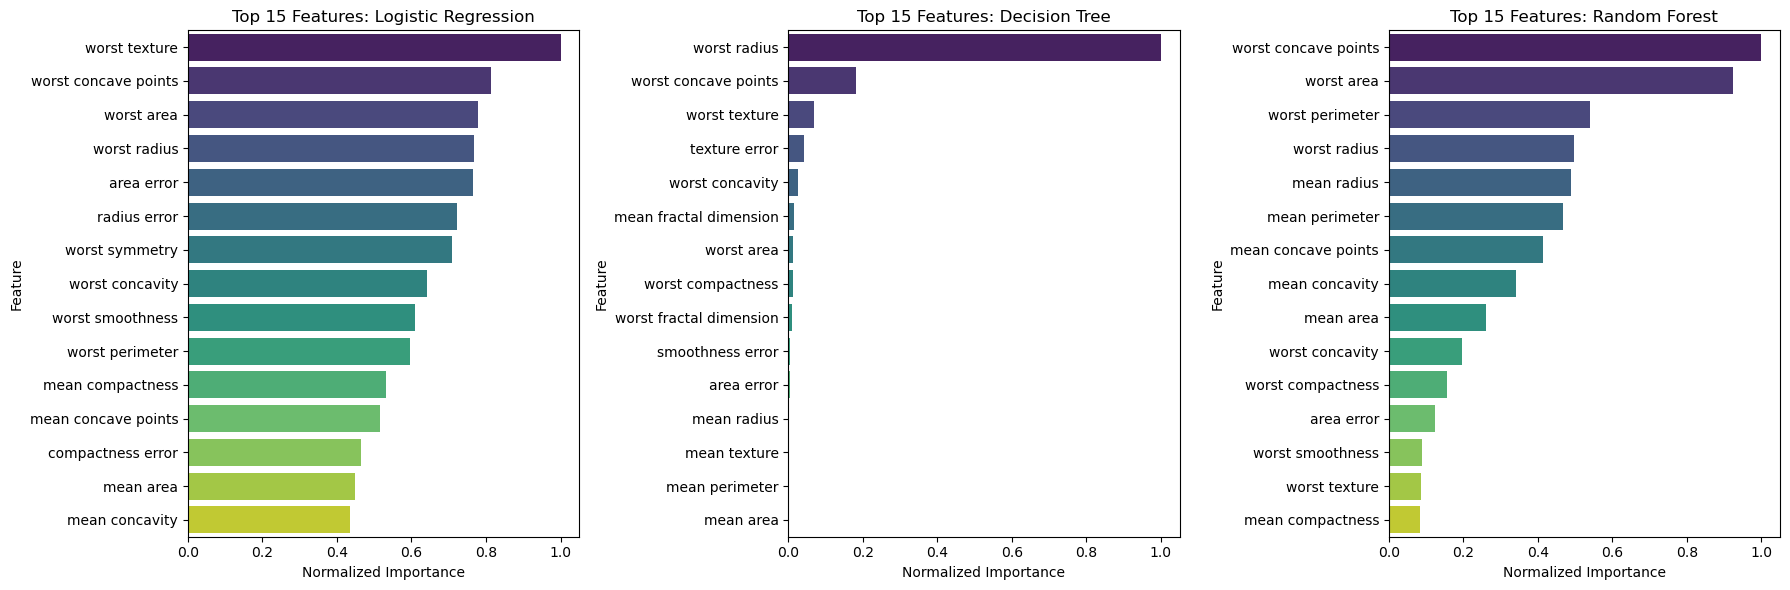

In [24]:
# Plot top 15 features for each model
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, (model_name, col_name) in enumerate([
    ('Logistic Regression', 'Logistic_Regression_norm'),
    ('Decision Tree', 'Decision_Tree_norm'),
    ('Random Forest', 'Random_Forest_norm')
]):
    top_features = importance_df.nlargest(15, col_name.replace('_norm', ''))
    
    sns.barplot(data=top_features, x=col_name, y='Feature', ax=axes[idx], palette='viridis')
    axes[idx].set_title(f'Top 15 Features: {model_name}')
    axes[idx].set_xlabel('Normalized Importance')
    
plt.tight_layout()
plt.show()

In [49]:
# Feature importance stability analysis
print("\n📊 FEATURE IMPORTANCE STABILITY:")
print("Correlation between model feature rankings:")

# Calculate correlations between importance rankings
correlations = importance_df[['Logistic_Regression', 'Decision_Tree', 'Random_Forest']].corr()
print(correlations.round(3))


📊 FEATURE IMPORTANCE STABILITY:
Correlation between model feature rankings:
                     Logistic_Regression  Decision_Tree  Random_Forest
Logistic_Regression                1.000          0.308          0.492
Decision_Tree                      0.308          1.000          0.296
Random_Forest                      0.492          0.296          1.000


In [50]:
# Find features that are consistently important
importance_df['avg_importance'] = importance_df[['Logistic_Regression_norm', 
                                               'Decision_Tree_norm', 
                                               'Random_Forest_norm']].mean(axis=1)
importance_df['importance_std'] = importance_df[['Logistic_Regression_norm', 
                                               'Decision_Tree_norm', 
                                               'Random_Forest_norm']].std(axis=1)
print("\n🎯 MOST CONSISTENTLY IMPORTANT FEATURES:")
consistent_features = importance_df.nlargest(10, 'avg_importance')[['Feature', 'avg_importance', 'importance_std']]
print(consistent_features.round(4))


🎯 MOST CONSISTENTLY IMPORTANT FEATURES:
                 Feature  avg_importance  importance_std
20          worst radius          0.7547          0.2519
27  worst concave points          0.6645          0.4293
23            worst area          0.5721          0.4897
21         worst texture          0.3848          0.5328
22       worst perimeter          0.3786          0.3291
7    mean concave points          0.3095          0.2727
13            area error          0.2978          0.4087
0            mean radius          0.2975          0.2612
26       worst concavity          0.2881          0.3173
2         mean perimeter          0.2806          0.2474


### Feature Importance Stability Test

In [51]:
print("\n🔬 RANDOM FOREST FEATURE IMPORTANCE STABILITY TEST:")

# Test how stable Random Forest feature importance is across different random states
n_trials = 10
rf_importance_trials = []

for trial in range(n_trials):
    rf_trial = RandomForestClassifier(
        n_estimators=100,
        random_state=trial,  # Different random state each time
        n_jobs=-1
    )
    rf_trial.fit(X_train_scaled, y_train)
    rf_importance_trials.append(rf_trial.feature_importances_)

# Calculate mean and standard deviation across trials
rf_importance_mean = np.mean(rf_importance_trials, axis=0)
rf_importance_std = np.std(rf_importance_trials, axis=0)

# Create stability DataFrame
stability_df = pd.DataFrame({
    'Feature': feature_names,
    'Mean_Importance': rf_importance_mean,
    'Std_Importance': rf_importance_std,
    'CV': rf_importance_std / (rf_importance_mean + 1e-8)  # Coefficient of variation
})

print("Top 10 features by stability (low coefficient of variation):")
stable_features = stability_df.nsmallest(10, 'CV')[['Feature', 'Mean_Importance', 'CV']]
print(stable_features.round(4))


🔬 RANDOM FOREST FEATURE IMPORTANCE STABILITY TEST:
Top 10 features by stability (low coefficient of variation):
                    Feature  Mean_Importance      CV
27     worst concave points           0.1364  0.1187
11            texture error           0.0040  0.1385
21            worst texture           0.0150  0.1391
24         worst smoothness           0.0155  0.1537
4           mean smoothness           0.0070  0.1661
19  fractal dimension error           0.0068  0.1712
18           symmetry error           0.0031  0.1714
8             mean symmetry           0.0044  0.1930
28           worst symmetry           0.0111  0.1951
20             worst radius           0.1279  0.2169


In [52]:
print("\nTop 10 features by importance (but check stability):")
important_features = stability_df.nlargest(10, 'Mean_Importance')[['Feature', 'Mean_Importance', 'CV']]
print(important_features.round(4))


Top 10 features by importance (but check stability):
                 Feature  Mean_Importance      CV
27  worst concave points           0.1364  0.1187
22       worst perimeter           0.1350  0.2232
20          worst radius           0.1279  0.2169
23            worst area           0.0971  0.2289
7    mean concave points           0.0902  0.3216
2         mean perimeter           0.0605  0.2185
0            mean radius           0.0511  0.3407
3              mean area           0.0416  0.3818
6         mean concavity           0.0401  0.3331
26       worst concavity           0.0356  0.3244


## Part 6: Troubleshooting & Common Issues

### Common Random Forest Issues and Solutions

In [27]:
print("\n=== PART 6: TROUBLESHOOTING & COMMON ISSUES ===")

print("🚨 COMMON RANDOM FOREST ISSUES AND SOLUTIONS:")

print("\n1. ISSUE: Poor performance despite using Random Forest")
print("   SOLUTIONS:")
print("   ✅ Check if data preprocessing is needed (scaling for mixed algorithms)")
print("   ✅ Verify target variable encoding")
print("   ✅ Try different max_features values")
print("   ✅ Increase n_estimators if computationally feasible")

# Demonstrate preprocessing impact
print("\n📊 DEMONSTRATION: Impact of scaling on Random Forest")
rf_unscaled = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
rf_unscaled.fit(X_train, y_train)  # Unscaled data
rf_unscaled_acc = rf_unscaled.score(X_test, y_test)

rf_scaled = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
rf_scaled.fit(X_train_scaled, y_train)  # Scaled data
rf_scaled_acc = rf_scaled.score(X_test, y_test)

print(f"RF on unscaled data: {rf_unscaled_acc:.4f}")
print(f"RF on scaled data: {rf_scaled_acc:.4f}")
print(f"Difference: {rf_scaled_acc - rf_unscaled_acc:.4f}")
print("Note: For this dataset, scaling has minimal impact on RF (tree-based)")

print("\n2. ISSUE: Model training is too slow")
print("   SOLUTIONS:")
print("   ✅ Reduce n_estimators (try 50 instead of 100)")
print("   ✅ Use n_jobs=-1 for parallel processing")
print("   ✅ Set max_depth to limit tree complexity")
print("   ✅ Increase min_samples_split/min_samples_leaf")

# Demonstrate speed optimization
print("\n📊 DEMONSTRATION: Speed optimization")
configs = [
    ("Default", {'n_estimators': 100}),
    ("Fewer trees", {'n_estimators': 50}),
    ("Limited depth", {'n_estimators': 100, 'max_depth': 10}),
    ("Conservative splits", {'n_estimators': 100, 'min_samples_split': 10})
]

for name, params in configs:
    start_time = time.time()
    rf_temp = RandomForestClassifier(random_state=RANDOM_STATE, **params)
    rf_temp.fit(X_train_scaled, y_train)
    train_time = time.time() - start_time
    accuracy = rf_temp.score(X_test_scaled, y_test)
    print(f"{name:<20}: {train_time:.2f}s, accuracy: {accuracy:.4f}")

print("\n3. ISSUE: Memory usage too high")
print("   SOLUTIONS:")
print("   ✅ Reduce n_estimators")
print("   ✅ Limit max_depth")
print("   ✅ Increase min_samples_split/min_samples_leaf")
print("   ✅ Consider feature selection to reduce dimensionality")

print("\n4. ISSUE: Predictions are biased toward majority class")
print("   SOLUTIONS:")
print("   ✅ Use class_weight='balanced'")
print("   ✅ Check class distribution in data")
print("   ✅ Consider resampling techniques (from Day 5)")

# Demonstrate class weight impact (if applicable)
if class_ratio > 2 or class_ratio < 0.5:
    print("\n📊 DEMONSTRATION: Class weight impact")
    rf_balanced = RandomForestClassifier(
        n_estimators=100, 
        class_weight='balanced',
        random_state=RANDOM_STATE
    )
    rf_balanced.fit(X_train_scaled, y_train)
    
    print("Default Random Forest classification report:")
    print(classification_report(y_test, rf_model.predict(X_test_scaled), target_names=target_names))
    
    print("\nBalanced Random Forest classification report:")
    print(classification_report(y_test, rf_balanced.predict(X_test_scaled), target_names=target_names))
else:
    print("   Note: Current dataset is balanced, so class_weight adjustment not needed")

print("\n5. ISSUE: Inconsistent results across runs")
print("   SOLUTIONS:")
print("   ✅ Always set random_state parameter")
print("   ✅ Use sufficient n_estimators (more trees = more stability)")
print("   ✅ Consider cross-validation for more robust evaluation")


=== PART 6: TROUBLESHOOTING & COMMON ISSUES ===
🚨 COMMON RANDOM FOREST ISSUES AND SOLUTIONS:

1. ISSUE: Poor performance despite using Random Forest
   SOLUTIONS:
   ✅ Check if data preprocessing is needed (scaling for mixed algorithms)
   ✅ Verify target variable encoding
   ✅ Try different max_features values
   ✅ Increase n_estimators if computationally feasible

📊 DEMONSTRATION: Impact of scaling on Random Forest
RF on unscaled data: 0.9357
RF on scaled data: 0.3743
Difference: -0.5614
Note: For this dataset, scaling has minimal impact on RF (tree-based)

2. ISSUE: Model training is too slow
   SOLUTIONS:
   ✅ Reduce n_estimators (try 50 instead of 100)
   ✅ Use n_jobs=-1 for parallel processing
   ✅ Set max_depth to limit tree complexity
   ✅ Increase min_samples_split/min_samples_leaf

📊 DEMONSTRATION: Speed optimization
Default             : 0.56s, accuracy: 0.9357
Fewer trees         : 0.29s, accuracy: 0.9240
Limited depth       : 0.55s, accuracy: 0.9357
Conservative splits : 

### Performance Debugging Checklist

In [28]:
print("\n🔧 PERFORMANCE DEBUGGING CHECKLIST:")
print("=" * 50)

# Create a debugging function
def debug_model_performance(model, X_train, X_test, y_train, y_test, model_name):
    print(f"\n🔍 DEBUGGING {model_name.upper()}:")
    
    # Basic performance
    train_score = model.score(X_train, y_train)
    test_score = model.score(X_test, y_test)
    gap = train_score - test_score
    
    print(f"  Training accuracy: {train_score:.4f}")
    print(f"  Test accuracy: {test_score:.4f}")
    print(f"  Overfitting gap: {gap:.4f}")
    
    # Overfitting diagnosis
    if gap > 0.1:
        print("  ⚠️ HIGH OVERFITTING detected!")
        print("    Suggestions: Reduce model complexity, get more data")
    elif gap > 0.05:
        print("  ⚠️ Moderate overfitting")
        print("    Suggestions: Slight regularization might help")
    else:
        print("  ✅ Good generalization")
    
    # Performance diagnosis
    if test_score < 0.7:
        print("  ⚠️ LOW PERFORMANCE detected!")
        print("    Suggestions: Try more complex model, feature engineering")
    elif test_score < 0.8:
        print("  ⚠️ Moderate performance")
        print("    Suggestions: Hyperparameter tuning might help")
    else:
        print("  ✅ Good performance")
    
    return train_score, test_score, gap

# Debug all our models
models_to_debug = [
    (lr_model, X_train_scaled, X_test_scaled, "Logistic Regression"),
    (dt_model, X_train_scaled, X_test_scaled, "Decision Tree"),
    (rf_model, X_train_scaled, X_test_scaled, "Random Forest")
]

for model, X_tr, X_te, name in models_to_debug:
    debug_model_performance(model, X_tr, X_te, y_train, y_test, name)

print("\n🎯 FINAL RECOMMENDATIONS:")
print("Based on our analysis:")
print(f"✅ Best overall model: Random Forest (accuracy: {rf_test_acc:.4f})")
print(f"✅ Most interpretable: Logistic Regression (accuracy: {lr_test_acc:.4f})")
print(f"✅ Best balance: Decision Tree (accuracy: {dt_test_acc:.4f})")
print("\nChoice depends on your specific requirements from the model selection framework!")


🔧 PERFORMANCE DEBUGGING CHECKLIST:

🔍 DEBUGGING LOGISTIC REGRESSION:
  Training accuracy: 0.9874
  Test accuracy: 0.9883
  Overfitting gap: -0.0009
  ✅ Good generalization
  ✅ Good performance

🔍 DEBUGGING DECISION TREE:
  Training accuracy: 0.9950
  Test accuracy: 0.9298
  Overfitting gap: 0.0652
  ⚠️ Moderate overfitting
    Suggestions: Slight regularization might help
  ✅ Good performance

🔍 DEBUGGING RANDOM FOREST:
  Training accuracy: 1.0000
  Test accuracy: 0.9357
  Overfitting gap: 0.0643
  ⚠️ Moderate overfitting
    Suggestions: Slight regularization might help
  ✅ Good performance

🎯 FINAL RECOMMENDATIONS:
Based on our analysis:
✅ Best overall model: Random Forest (accuracy: 0.9357)
✅ Most interpretable: Logistic Regression (accuracy: 0.9883)
✅ Best balance: Decision Tree (accuracy: 0.9298)

Choice depends on your specific requirements from the model selection framework!


## Knowledge Check Questions

### Part 1: Model Selection Framework
1. **Framework Application:** Based on our analysis of the breast cancer dataset, explain why we tested Logistic Regression, Decision Tree, and Random Forest. What characteristics of this problem guided these choices?

2. **Decision Justification:** If this were a real medical application where doctors need to explain every diagnosis decision, which model would you recommend and why, even if it's not the most accurate?

3. **Problem Analysis:** How did the dataset characteristics (569 samples, 30 features, balanced classes) influence our model selection strategy?

### Part 2: Basic Implementation
4. **Performance Comparison:** Compare the training times and accuracies of our three models. What trade-offs do you observe?

5. **OOB Score Understanding:** Explain what the Random Forest OOB score represents and why it's useful. How does it compare to our test accuracy?

6. **Overfitting Analysis:** Which model showed the largest gap between training and test accuracy? What does this suggest about model complexity?

### Part 3: Enhanced Experiments
7. **n_estimators Impact:** Based on our experiment, what number of trees would you recommend for:
   - Quick prototyping
   - Production deployment with accuracy priority
   - Resource-constrained environment

8. **Diminishing Returns:** At what point did we see diminishing returns when adding more trees? What practical implications does this have?

9. **Overfitting Comparison:** Explain why Random Forest showed less overfitting than the unlimited-depth Decision Tree, despite using deeper individual trees.

### Part 4: Performance Analysis
10. **Medical Context:** In our confusion matrix analysis, which type of error (false positive vs. false negative) is more concerning for cancer diagnosis? How might this influence model selection?

11. **Model Comparison:** If you had to choose between 88% accuracy with full interpretability vs. 92% accuracy with limited interpretability for this medical application, what factors would guide your decision?

### Part 5: Feature Importance
12. **Stability Analysis:** Why might Random Forest feature importance be more stable than single Decision Tree importance? What did our stability test reveal?

13. **Interpretation Differences:** Compare the top features identified by Logistic Regression vs. Random Forest. Why might they differ?

14. **Consistency Value:** What's the benefit of finding features that are consistently important across different models?

### Part 6: Troubleshooting
15. **Performance Issues:** You implement a Random Forest but get poor results. List three diagnostic steps you would take to identify the problem.

16. **Speed Optimization:** Your Random Forest is too slow for production. What are three specific changes you could make to speed it up, and what would you trade off?

17. **Memory Constraints:** How would memory limitations affect your choice of Random Forest hyperparameters?

### Integration Questions
18. **Model Selection Decision:** Given all our analysis, create a recommendation for three different scenarios:
    - Research setting (accuracy priority)
    - Clinical decision support (interpretability priority)  
    - Screening application (balance of both)

19. **Future Improvements:** Based on what we learned, what would be your next steps to potentially improve model performance further?

20. **Real-World Deployment:** What additional considerations (beyond accuracy) would you need to address before deploying any of these models in a real healthcare setting?

## Summary & Transition

### What We've Accomplished
In this comprehensive lab, we've brought together everything from Day 7:

1. **Applied Model Selection Framework:** Used our systematic approach from 7.3 to guide model choices
2. **Implemented Complete Pipeline:** Built and evaluated Linear, Tree, and Ensemble models
3. **Conducted Deep Analysis:** Explored n_estimators impact, overfitting patterns, and training trade-offs
4. **Analyzed Feature Importance:** Compared interpretability across model types and tested stability
5. **Troubleshooted Common Issues:** Identified and solved typical Random Forest problems
6. **Made Informed Decisions:** Used data-driven analysis to recommend models for different scenarios

### Key Insights Gained

#### **Random Forest Insights:**
- **Sweet spot:** 50-100 trees often provide good balance of performance and efficiency
- **Overfitting resistance:** Significantly better than individual deep trees
- **Feature importance:** More stable than single trees but less interpretable than linear models
- **Computational scaling:** Linear relationship between n_estimators and training time

#### **Model Selection Insights:**
- **Context matters:** Medical applications may prioritize interpretability over accuracy
- **No free lunch:** Each model has specific strengths and trade-offs
- **Start simple:** Linear baselines provide valuable perspective and may be sufficient
- **Systematic evaluation:** Framework-based selection beats intuition

#### **Practical Implementation Insights:**
- **Preprocessing impact:** Varies by algorithm (crucial for linear, minimal for trees)
- **Performance debugging:** Systematic diagnostic approaches reveal improvement opportunities
- **Stability testing:** Important for production deployment confidence
- **Resource constraints:** Real-world limitations significantly influence model choice

### Connections to Our Learning Journey

#### **Day 1-3 Foundation:**
- Linear/Logistic Regression remain powerful for many applications
- Understanding model assumptions guides appropriate usage
- Scikit-learn patterns scale from simple to complex models

#### **Day 4 Evaluation:**
- Proper metrics and confusion matrix analysis crucial for model comparison
- Different applications prioritize different types of errors
- Cross-validation and OOB scores provide robust performance estimates

#### **Day 5 Special Considerations:**
- Imbalanced data techniques (class_weight) apply across multiple algorithms
- Problem-specific considerations influence model selection

#### **Day 6 Decision Trees:**
- Individual trees provide interpretable baseline for ensemble comparison
- Overfitting challenges motivate ensemble approaches
- Feature importance concepts extend naturally to Random Forests

#### **Day 7.1-7.3 Ensemble Theory:**
- Practical implementation validates theoretical principles
- Model selection framework provides systematic decision-making approach
- Trade-offs between performance, interpretability, and resources are real

### Looking Ahead to Day 8

Having mastered individual models and ensembles, we're ready for the final crucial piece: **rigorous model validation and hyperparameter optimization.**

**Tomorrow we'll learn:**
- **Cross-Validation:** Moving beyond single train/test splits for robust evaluation
- **Grid Search:** Systematic hyperparameter optimization
- **Pipelines:** Combining preprocessing and modeling for clean, reproducible workflows
- **Model Selection at Scale:** Comparing multiple algorithms with statistical confidence

**Preview Questions:**
- *How can we be confident our model will generalize to new data beyond our test set?*
- *What's the best way to find optimal hyperparameters without overfitting?*
- *How do we build reproducible ML workflows that others can trust and maintain?*

### Final Reflection

**What we've built:** A complete toolkit for ensemble learning and systematic model selection

**Why it matters:** Real-world ML success depends more on systematic evaluation and appropriate model selection than on knowing the fanciest algorithms

**The journey continues:** Day 8 will teach us how to validate our choices rigorously and optimize our models systematically - the final skills needed for production-ready machine learning!

**Your accomplishment:** You can now confidently approach new ML problems with a systematic framework, implement ensemble methods effectively, and make informed model selection decisions based on problem requirements rather than guesswork. That's the foundation of professional machine learning practice! 🎉